<a href="https://colab.research.google.com/github/alyona-vishnoi/music-streaming-nba-rl/blob/main/01_music_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Music Streaming NBA Simulator
### A Next Best Action environment for offline RL experiments

This notebook builds the core simulation environment — user states,
channel actions, transition dynamics, and the three reward functions
we'll compare: CTR, weighted sum, and LTV proxy.

In [ ]:
import numpy as np
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class Simulator():
  def __init__(self):
    self.states = ["active_daily", "active_weekly", "lapsed_7d", "lapsed_30d", "churning"]
    self.actions = ["email_digest", "push_notif", "in_app_banner", "new_mix", "do_nothing"]
    self.state_idx = {
        "active_daily" : 0,
        "active_weekly" : 1,
        "lapsed_7d" : 2,
        "lapsed_30d" : 3,
        "churning" : 4
    }
    self.action_idx = {
        "email_digest" : 0,
        "push_notif" : 1,
        "in_app_banner" : 2,
        "new_mix" : 3,
        "do_nothing" : 4
    }
    self.transition_probs = {
        # active_daily — already our best users
        # good actions keep them there, bad actions barely hurt
        ('active_daily', 'email_digest'):  {'active_daily': 0.7, 'active_weekly': 0.2, 'lapsed_7d': 0.05, 'lapsed_30d': 0.03, 'churning': 0.02},
        ('active_daily', 'push_notif'):    {'active_daily': 0.6, 'active_weekly': 0.25, 'lapsed_7d': 0.1, 'lapsed_30d': 0.03, 'churning': 0.02},
        ('active_daily', 'in_app_banner'): {'active_daily': 0.75, 'active_weekly': 0.15, 'lapsed_7d': 0.05, 'lapsed_30d': 0.03, 'churning': 0.02},
        ('active_daily', 'new_mix'):       {'active_daily': 0.85, 'active_weekly': 0.1, 'lapsed_7d': 0.03, 'lapsed_30d': 0.01, 'churning': 0.01},
        ('active_daily', 'do_nothing'):    {'active_daily': 0.55, 'active_weekly': 0.3, 'lapsed_7d': 0.1, 'lapsed_30d': 0.03, 'churning': 0.02},

        # active_weekly — moderately engaged, right action can push to daily
        ('active_weekly', 'email_digest'):  {'active_daily': 0.15, 'active_weekly': 0.55, 'lapsed_7d': 0.2, 'lapsed_30d': 0.07, 'churning': 0.03},
        ('active_weekly', 'push_notif'):    {'active_daily': 0.1, 'active_weekly': 0.5, 'lapsed_7d': 0.25, 'lapsed_30d': 0.1, 'churning': 0.05},
        ('active_weekly', 'in_app_banner'): {'active_daily': 0.2, 'active_weekly': 0.55, 'lapsed_7d': 0.15, 'lapsed_30d': 0.07, 'churning': 0.03},
        ('active_weekly', 'new_mix'):       {'active_daily': 0.3, 'active_weekly': 0.55, 'lapsed_7d': 0.1, 'lapsed_30d': 0.04, 'churning': 0.01},
        ('active_weekly', 'do_nothing'):    {'active_daily': 0.05, 'active_weekly': 0.4, 'lapsed_7d': 0.35, 'lapsed_30d': 0.15, 'churning': 0.05},

        # lapsed_7d — gone a week, still recoverable with right action
        ('lapsed_7d', 'email_digest'):  {'active_daily': 0.1, 'active_weekly': 0.35, 'lapsed_7d': 0.35, 'lapsed_30d': 0.15, 'churning': 0.05},
        ('lapsed_7d', 'push_notif'):    {'active_daily': 0.05, 'active_weekly': 0.2, 'lapsed_7d': 0.35, 'lapsed_30d': 0.3, 'churning': 0.1},
        ('lapsed_7d', 'in_app_banner'): {'active_daily': 0.05, 'active_weekly': 0.25, 'lapsed_7d': 0.4, 'lapsed_30d': 0.2, 'churning': 0.1},
        ('lapsed_7d', 'new_mix'):       {'active_daily': 0.15, 'active_weekly': 0.4, 'lapsed_7d': 0.3, 'lapsed_30d': 0.1, 'churning': 0.05},
        ('lapsed_7d', 'do_nothing'):    {'active_daily': 0.02, 'active_weekly': 0.1, 'lapsed_7d': 0.3, 'lapsed_30d': 0.4, 'churning': 0.18},

        # lapsed_30d — gone a month, harder to recover
        ('lapsed_30d', 'email_digest'):  {'active_daily': 0.05, 'active_weekly': 0.15, 'lapsed_7d': 0.2, 'lapsed_30d': 0.45, 'churning': 0.15},
        ('lapsed_30d', 'push_notif'):    {'active_daily': 0.03, 'active_weekly': 0.1, 'lapsed_7d': 0.15, 'lapsed_30d': 0.42, 'churning': 0.3},
        ('lapsed_30d', 'in_app_banner'): {'active_daily': 0.02, 'active_weekly': 0.08, 'lapsed_7d': 0.15, 'lapsed_30d': 0.5, 'churning': 0.25},
        ('lapsed_30d', 'new_mix'):       {'active_daily': 0.08, 'active_weekly': 0.2, 'lapsed_7d': 0.25, 'lapsed_30d': 0.35, 'churning': 0.12},
        ('lapsed_30d', 'do_nothing'):    {'active_daily': 0.01, 'active_weekly': 0.04, 'lapsed_7d': 0.1, 'lapsed_30d': 0.4, 'churning': 0.45},

        # churning — about to cancel, hardest to recover
        ('churning', 'email_digest'):  {'active_daily': 0.03, 'active_weekly': 0.1, 'lapsed_7d': 0.15, 'lapsed_30d': 0.22, 'churning': 0.5},
        ('churning', 'push_notif'):    {'active_daily': 0.02, 'active_weekly': 0.08, 'lapsed_7d': 0.1, 'lapsed_30d': 0.2, 'churning': 0.6},
        ('churning', 'in_app_banner'): {'active_daily': 0.02, 'active_weekly': 0.07, 'lapsed_7d': 0.11, 'lapsed_30d': 0.2, 'churning': 0.6},
        ('churning', 'new_mix'):       {'active_daily': 0.05, 'active_weekly': 0.15, 'lapsed_7d': 0.2, 'lapsed_30d': 0.25, 'churning': 0.35},
        ('churning', 'do_nothing'):    {'active_daily': 0.01, 'active_weekly': 0.02, 'lapsed_7d': 0.07, 'lapsed_30d': 0.2, 'churning': 0.7},
    }
  def reset(self):
    # return a random starting state
    return random.choice(self.states)

  def step(self, state, action):
    # 1. sample next state
    probs = self.transition_probs[(state, action)]
    next_state = random.choices(
        list(probs.keys()),
        weights=list(probs.values())
    )[0]

    # 2. generate channel metrics based on state and action
    metrics = self._generate_metrics(state, action)

    return next_state, metrics

  def _generate_metrics(self, state, action):
      # engagement multiplier — scales all probabilities by user state
      engagement = {
          'active_daily': 0.9,
          'active_weekly': 0.7,
          'lapsed_7d': 0.4,
          'lapsed_30d': 0.2,
          'churning': 0.1,
      }
      e = engagement[state]

      if action == 'email_digest':
          opened = 1 if random.random() < 0.4 * e else 0
          clicked = 1 if (opened and random.random() < 0.3 * e) else 0
          streams = np.random.poisson(15 * e) if clicked else np.random.poisson(3 * e)
          return {
              'opened': opened,
              'clicked': clicked,
              'streams_next_7d': float(streams),
          }

      elif action == 'push_notif':
          opened = 1 if random.random() < 0.5 * e else 0
          session_started = 1 if (opened and random.random() < 0.6 * e) else 0
          # annoyed users disable notifications — more likely when lapsed
          disabled = 1 if random.random() < 0.05 * (1 - e) else 0
          return {
              'opened': opened,
              'session_started': session_started,
              'disabled_notifs': disabled,
          }

      elif action == 'in_app_banner':
          # lapsed users aren't in the app — banner rarely seen
          seen = 1 if random.random() < 0.6 * e else 0
          dismissed = 1 if (seen and random.random() < 0.5) else 0
          clicked = 1 if (seen and not dismissed and random.random() < 0.4 * e) else 0
          dwell  = float(np.random.exponential(10 * e)) if clicked else 0.0
          return {
              'dismissed': dismissed,
              'clicked': clicked,
              'dwell_seconds': dwell,
          }

      elif action == 'new_mix':
          mix_opened  = 1 if random.random() < 0.5 * e else 0
          songs = np.random.poisson(8 * e) if mix_opened else 0
          mix_saved = 1 if (mix_opened and random.random() < 0.3 * e) else 0
          return {
              'mix_opened': mix_opened,
              'songs_streamed': float(songs),
              'mix_saved': mix_saved,
          }

      elif action == 'do_nothing':
          # organic streaming — depends entirely on user state
          streams = np.random.poisson(10 * e)
          return {
              'streams_this_week': float(streams),
          }


In [ ]:
# Sanity check
env = Simulator()

# test reset
state = env.reset()
print(f"starting state: {state}")

# test step for each action
for action in env.actions:
    next_state, metrics = env.step(state, action)
    print(f"\nstate={state}, action={action}")
    print(f"  next_state: {next_state}")
    print(f"  metrics:    {metrics}")

starting state: lapsed_7d

state=lapsed_7d, action=email_digest
  next_state: churning
  metrics:    {'opened': 1, 'clicked': 0, 'streams_next_7d': 1.0}

state=lapsed_7d, action=push_notif
  next_state: lapsed_7d
  metrics:    {'opened': 0, 'session_started': 0, 'disabled_notifs': 0}

state=lapsed_7d, action=in_app_banner
  next_state: lapsed_7d
  metrics:    {'dismissed': 0, 'clicked': 0, 'dwell_seconds': 0.0}

state=lapsed_7d, action=new_mix
  next_state: active_weekly
  metrics:    {'mix_opened': 0, 'songs_streamed': 0.0, 'mix_saved': 0}

state=lapsed_7d, action=do_nothing
  next_state: active_weekly
  metrics:    {'streams_this_week': 1.0}


In [ ]:
# Basic behaviour policy
def behavior_policy(state):
    """
    Old system — basic rule-based personalisation.
    Some state awareness but not optimal.
    """
    if state == 'active_daily':
        # active users get in-app content, light email
        probs = {
            'email_digest': 0.2,
            'push_notif': 0.15,
            'in_app_banner': 0.4,
            'new_mix': 0.2,
            'do_nothing': 0.05,
        }
    elif state == 'active_weekly':
        # weekly users get nudged toward more engagement
        probs = {
            'email_digest': 0.35,
            'push_notif': 0.2,
            'in_app_banner': 0.25,
            'new_mix': 0.15,
            'do_nothing': 0.05,
        }
    elif state == 'lapsed_7d':
        # recently lapsed get re-engagement email
        probs = {
            'email_digest': 0.5,
            'push_notif': 0.2,
            'in_app_banner': 0.1,
            'new_mix': 0.1,
            'do_nothing': 0.1,
        }
    elif state == 'lapsed_30d':
      probs = {
          'email_digest':  0.25,
          'push_notif':    0.25,
          'in_app_banner': 0.15,
          'new_mix':       0.25,
          'do_nothing':    0.10,
      }

    else:  # churning
        probs = {
            'email_digest':  0.25,
            'push_notif':    0.25,
            'in_app_banner': 0.15,
            'new_mix':       0.25,
            'do_nothing':    0.10,
        }

    action = random.choices(list(probs.keys()), weights=list(probs.values()))[0]
    propensity = probs[action]
    return action, propensity

In [ ]:
# check behavior policy covers all states
for state in env.states:
    action, propensity = behavior_policy(state)
    print(f"{state:15s} -> {action:15s} (propensity: {propensity})")

active_daily    -> email_digest    (propensity: 0.2)
active_weekly   -> push_notif      (propensity: 0.2)
lapsed_7d       -> do_nothing      (propensity: 0.1)
lapsed_30d      -> new_mix         (propensity: 0.25)
churning        -> new_mix         (propensity: 0.25)


In [ ]:
# Log generation
def generate_logs(env, n_steps=50000):
    logs = []
    state = env.reset()

    for _ in range(n_steps):
        action, propensity = behavior_policy(state)
        next_state, metrics = env.step(state, action)

        logs.append({
            'state': state,
            'action': action,
            'propensity': propensity,
            'metrics': metrics,
            'next_state': next_state,
        })

        state = next_state

    return pd.DataFrame(logs)

logs = generate_logs(env, n_steps=50000)
print(f"total rows: {len(logs)}")
print(f"\naction distribution:\n{logs['action'].value_counts()}")
print(f"\nstate distribution:\n{logs['state'].value_counts()}")
print(f"\nsample row:")
print(logs.iloc[0])

total rows: 50000

action distribution:
action
email_digest     15354
in_app_banner    11760
push_notif       10076
new_mix           9248
do_nothing        3562
Name: count, dtype: int64

state distribution:
state
active_weekly    13913
active_daily     13252
lapsed_7d         8458
lapsed_30d        7939
churning          6438
Name: count, dtype: int64

sample row:
state                                                 lapsed_7d
action                                             email_digest
propensity                                                  0.5
metrics       {'opened': 0, 'clicked': 0, 'streams_next_7d':...
next_state                                            lapsed_7d
Name: 0, dtype: object


Notes:

*   The behavior policy underuses new_mix (only 18.5% of actions) even though it's the strongest re-engagement channel.
*   Nearly 13% of all user-weeks are spent in the churning state. That is the cost of the behavior policy's mistakes. A better policy should reduce this significantly by catching users earlier with better actions.

## Reward Design

Three reward functions applied to the same simulator and logs.
The reward function is intentionally separate from the simulator.
The environment returns raw metrics, we decide how to interpret them.

- **Version 1**: Pure CTR - naive, gameable
- **Version 2**: Weighted sum — fragile, weight-sensitive  
- **Version 3**: LTV proxy — principled, grounded in retention

In [ ]:
# ── version 1: pure CTR ─────────────────────────────────────────────────

def ctr_reward(metrics, action):
    """
    Naive reward — only cares about immediate clicks and opens.
    Easy to measure, easy to game.
    An agent optimising this will spam push notifications
    and send clickbait emails regardless of user state.
    """
    if action == 'email_digest':
        return float(metrics['clicked'])

    elif action == 'push_notif':
        return float(metrics['opened'])

    elif action == 'in_app_banner':
        return float(metrics['clicked'])

    elif action == 'new_mix':
        return float(metrics['mix_opened'])

    elif action == 'do_nothing':
        return 0.0


# ── version 2: weighted sum ──────────────────────────────────────────────

def weighted_reward(metrics, action):
    """
    Weighted combination of engagement signals.
    Better than pure CTR but fragile because weights are arbitrary.
    Small changes to weights produce very different policies.
    """
    if action == 'email_digest':
        return (
            0.3 * metrics['opened'] +
            0.4 * metrics['clicked'] +
            0.3 * (metrics['streams_next_7d'] / 20) # normalise to [0,1]
        )

    elif action == 'push_notif':
        return (
            0.3 * metrics['opened'] +
            0.5 * metrics['session_started'] +
            0.2 * (-metrics['disabled_notifs']) # penalty for disabling
        )

    elif action == 'in_app_banner':
        return (
            0.2 * metrics['clicked'] +
            0.5 * (metrics['dwell_seconds'] / 30) + # normalise to [0,1]
            0.3 * (1 - metrics['dismissed']) # reward for not dismissing
        )

    elif action == 'new_mix':
        return (
            0.2 * metrics['mix_opened'] +
            0.5 * (metrics['songs_streamed'] / 20) +  # normalise to [0,1]
            0.3 * metrics['mix_saved']
        )

    elif action == 'do_nothing':
        return 0.1 * (metrics['streams_this_week'] / 10)  # normalise to [0,1]


# ── version 3: LTV proxy ─────────────────────────────────────────────────

def ltv_reward(metrics, action, state):
    """
    LTV reward — measures CHANGE in retention probability.
    Removes the base_retention term so we're measuring
    what the action contributed, not the user's baseline health.
    """
    streams  = metrics.get('streams_next_7d', 0) + \
               metrics.get('songs_streamed', 0) + \
               metrics.get('streams_this_week', 0)

    any_click = float(metrics.get('clicked', 0) or
                      metrics.get('opened', 0) or
                      metrics.get('mix_opened', 0))

    saved = float(metrics.get('mix_saved', 0))
    notification_disabled = float(metrics.get('disabled_notifs', 0))
    dismissed = float(metrics.get('dismissed', 0))

    # delta LTV — what did this action contribute?
    # no base_retention term — purely action effect
    delta_ltv = (
        0.15 * any_click +
        0.25 * (streams / 20) +
        0.20 * saved +
        -0.30 * notification_disabled +
        -0.10 * dismissed
    )

    return float(np.clip(delta_ltv, -1.0, 1.0))

In [ ]:
# add all three reward columns to the logs dataframe
logs['reward_ctr'] = logs.apply(
    lambda row: ctr_reward(row['metrics'], row['action']), axis=1)

logs['reward_weighted'] = logs.apply(
    lambda row: weighted_reward(row['metrics'], row['action']), axis=1)

logs['reward_ltv'] = logs.apply(
    lambda row: ltv_reward(row['metrics'], row['action'], row['state']), axis=1)

print("mean rewards per version:")
print(f" CTR: {logs['reward_ctr'].mean():.4f}")
print(f" weighted: {logs['reward_weighted'].mean():.4f}")
print(f" LTV: {logs['reward_ltv'].mean():.4f}")

print("\nmean reward by action (CTR):")
print(logs.groupby('action')['reward_ctr'].mean().sort_values(ascending=False))

print("\nmean reward by action (LTV):")
print(logs.groupby('action')['reward_ltv'].mean().sort_values(ascending=False))

mean rewards per version:
 CTR: 0.1243
 weighted: 0.1408
 LTV: 0.0371

mean reward by action (CTR):
action
new_mix          0.260597
push_notif       0.245137
in_app_banner    0.060204
email_digest     0.040771
do_nothing       0.000000
Name: reward_ctr, dtype: float64

mean reward by action (LTV):
action
new_mix          0.069884
do_nothing       0.056450
email_digest     0.055085
push_notif       0.029208
in_app_banner   -0.011386
Name: reward_ltv, dtype: float64


In [ ]:
print("mean reward by action AND state — CTR:")
print(logs.groupby(['state','action'])['reward_ctr'].mean().unstack().round(3))

print("\nmean reward by action AND state — LTV:")
print(logs.groupby(['state','action'])['reward_ltv'].mean().unstack().round(3))

mean reward by action AND state — CTR:
action         do_nothing  email_digest  in_app_banner  new_mix  push_notif
state                                                                      
active_daily          0.0         0.098          0.094    0.447       0.437
active_weekly         0.0         0.051          0.057    0.363       0.361
churning              0.0         0.003          0.002    0.051       0.055
lapsed_30d            0.0         0.006          0.005    0.091       0.095
lapsed_7d             0.0         0.024          0.006    0.187       0.187

mean reward by action AND state — LTV:
action         do_nothing  email_digest  in_app_banner  new_mix  push_notif
state                                                                      
active_daily        0.112         0.101         -0.013    0.133       0.064
active_weekly       0.090         0.073         -0.013    0.095       0.050
churning            0.013         0.010         -0.002    0.009      -0.004
lapsed_30

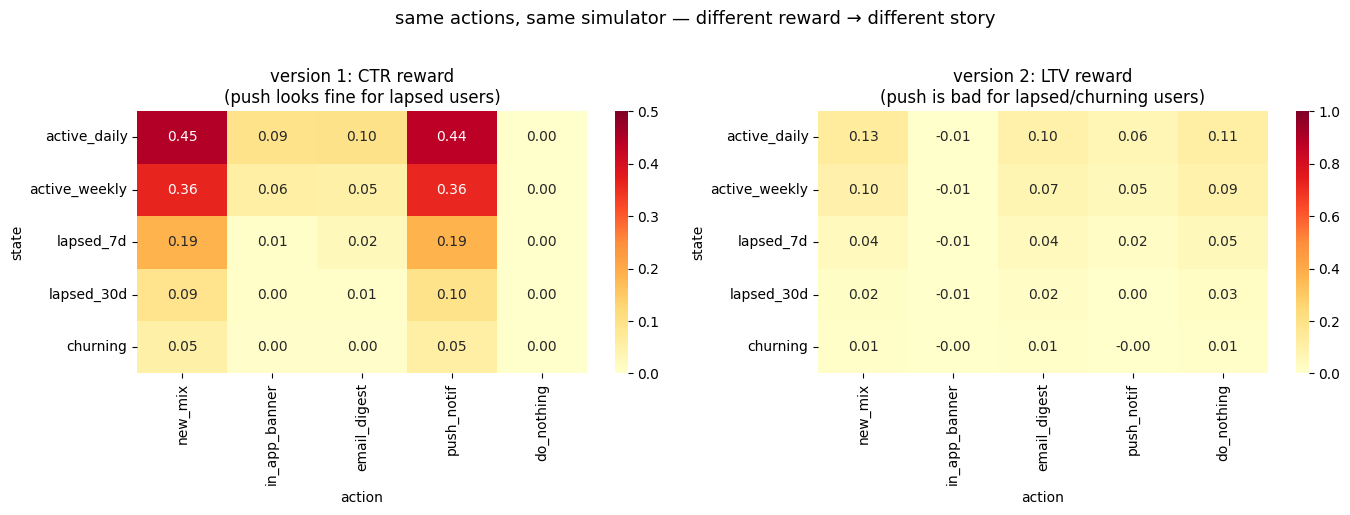

In [ ]:
# reward hacking visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pivot tables for heatmaps
ctr_pivot = logs.groupby(['state', 'action'])['reward_ctr'].mean().unstack()
ltv_pivot = logs.groupby(['state', 'action'])['reward_ltv'].mean().unstack()

# order states from most to least engaged
state_order  = ['active_daily', 'active_weekly', 'lapsed_7d', 'lapsed_30d', 'churning']
action_order = ['new_mix', 'in_app_banner', 'email_digest', 'push_notif', 'do_nothing']

ctr_pivot = ctr_pivot.loc[state_order, action_order]
ltv_pivot = ltv_pivot.loc[state_order, action_order]

sns.heatmap(ctr_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], vmin=0, vmax=0.5)
axes[0].set_title('version 1: CTR reward\n(push looks fine for lapsed users)')

sns.heatmap(ltv_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], vmin=0, vmax=1.0)
axes[1].set_title('version 2: LTV reward\n(push is bad for lapsed/churning users)')

plt.suptitle('same actions, same simulator — different reward → different story',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle

# save the raw logs dataframe
with open('/content/drive/MyDrive/music_nba_logs.pkl', 'wb') as f:
    pickle.dump(logs, f)

print(f"saved {len(logs)} transitions to Drive")
print(f"columns: {logs.columns.tolist()}")

Mounted at /content/drive
saved 50000 transitions to Drive
columns: ['state', 'action', 'propensity', 'metrics', 'next_state', 'reward_ctr', 'reward_weighted', 'reward_ltv']


In [ ]:
# save simulator state (transition probs etc)
with open('/content/drive/MyDrive/music_simulator.pkl', 'wb') as f:
    pickle.dump(env, f)

print("saved simulator to Drive")

saved simulator to Drive
